# Projet : Construction d'un Système de Recommandation avec LightFM
Ce notebook présente l'implémentation complète d'un système de recommandation basé sur le dataset H&M et la bibliothèque LightFM, conformément aux **consignes détaillées du projet** : [consignes du projet](https://docs.google.com/document/d/16ZCFuI9-aKwK2FuTMmAgbsrI7gbMFuswlYlmFF2MnkU/edit?usp=drive_link). Le pipeline comprend l'exploration des données, l'échantillonnage stratégique, le prétraitement, l'entraînement de modèles, l'optimisation des hyperparamètres, l'évaluation des performances, ainsi que le développement d'une approche hybride combinant filtrage collaboratif et métadonnées d'articles.



## Table des Matières

1. [Informations du Projet](#informations-du-projet)
2. [Auteurs](#auteurs)
3. [Comment Utiliser ce Notebook](#comment-utiliser-ce-notebook)
4. [Configuration de l'Environnement](#configuration-de-lenvironnement)
5. [Étape 1 : Exploration et Compréhension des Données](#étape-1--exploration-et-compréhension-des-données)
6. [Étape 2 : Stratégie d'Échantillonnage des Données](#étape-2--stratégie-déchantillonnage-des-données)
7. [Étape 3 : Prétraitement et Construction de la Matrice](#étape-3--prétraitement-et-construction-de-la-matrice)
8. [Étape 4 : Stratégie de Division Train/Test](#étape-4--stratégie-de-division-traintest)
9. [Étape 5 : Entraînement du Modèle](#étape-5--entraînement-du-modèle)
10. [Étape 6 : Optimisation des Hyperparamètres](#étape-6--optimisation-des-hyperparamètres)
11. [Étape 7 : Évaluation et Interprétation du Modèle](#étape-7--évaluation-et-interprétation-du-modèle)
12. [Étape 8 : Modèle Hybride avec Features d'Articles](#étape-8--modèle-hybride-avec-features-darticles)
13. [Analyse Comparative : Impact de la Taille d'Échantillon](#analyse-finale--impact-de-la-taille-déchantillon)
14. [Conclusion](#conclusion)
15. [Préparation du Déploiement MVP](#préparation-du-déploiement-mvp)
    - [Déploiement Local](#déploiement-local)
    - [Comment Utiliser l'Application](#-comment-utiliser-lapplication)
    - [Déploiement sur Streamlit Cloud](#️-déploiement-sur-streamlit-cloud)





---

## Informations du Projet
| **Attribut** | **Détails** |
|--------------|-------------|
| **Titre** | Pipeline de Recommandation de Mode H&M |
| **Dépôt GitHub** | [github.com/realnribal/hm-fashion-recommendation-pipeline](https://github.com/realnribal/hm-fashion-recommendation-pipeline) |
| **Type** | Système de recommandation pour le commerce électronique |
| **Framework Principal** |  [LightFM (Light Factorization Machines)](https://making.lyst.com/lightfm/docs/home.html) - [Dépôt GitHub](https://github.com/lyst/lightfm)|
| **Jeux de Données** | [Télécharger depuis Google Drive](https://drive.google.com/drive/folders/1QCnycWNFvy0iz3JXKhW--YlLNtwiLPSn?usp=drive_link) |
| **Consignes du Projet** | [Consignes du projet](https://docs.google.com/document/d/16ZCFuI9-aKwK2FuTMmAgbsrI7gbMFuswlYlmFF2MnkU/edit?usp=drive_link) |

---

## Auteurs

| **Auteur** | **Email** |
|-----------|-----------|
| Henri BALAMOU | henri.balamou@dauphine.eu |
| Rachna HEAN | rachna.hean@dauphine.eu |




## Comment Utiliser ce Notebook

### Instructions Rapides
1. **Ouvrir** : [Google Colab](https://colab.research.google.com) → Importer ce fichier `.ipynb`
2. **Préparer les données** : Placer `transactions_train.csv`, `articles.csv`, `customers.csv` dans Google Drive
3. **Exécuter** : "Exécuter tout" ou cellule par cellule (⌘/Ctrl + Entrée)
4. **Durée estimée** : 1-2 heures (selon les tailles d'échantillons)

### Prérequis
- Compte Google (pour Colab et Drive)
- Datasets H&M : [Télécharger ici](https://drive.google.com/drive/folders/1QCnycWNFvy0iz3JXKhW--YlLNtwiLPSn?usp=drive_link)

### Dépannage Courant
| **Problème** | **Solution** |
|--------------|--------------|
| Fichiers non trouvés | Vérifier `data_path` dans la cellule 5 |
| Mémoire insuffisante | Réduire `user_sample_sizes` dans la cellule 16 |
| Temps d'exécution long | Normal : entraînement = 5-10 min par taille |

### Personnalisation
- **Taille d'échantillon** : Modifier `user_sample_sizes = [1000, 5000, 10000]` (cellule 16)
- **Hyperparamètres** : Ajuster `components_list` et `learning_rates` (cellule 9)


## Configuration de l'Environnement

Cette section configure l'environnement de travail pour notre projet de système de recommandation. Nous allons :

1. **Monter Google Drive** pour accéder aux datasets
2. **Installer les bibliothèques** nécessaires (LightFM, etc.)
3. **Importer les modules** Python requis
4. **Charger les données** depuis les fichiers CSV

**Note importante** : Assurez-vous d'avoir placé les fichiers `transactions_train.csv`, `articles.csv`, et `customers.csv` dans votre Google Drive avant de continuer.

In [17]:


# Définir le chemin vers vos datasets (ajustez si nécessaire)
data_path = '../data/'  # Changez ceci selon votre chemin réel

In [18]:
# Importer les bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from lightfm import LightFM
from lightfm.evaluation import precision_at_k, recall_at_k, auc_score
from lightfm.data import Dataset
from sklearn.model_selection import train_test_split
import warnings
import time
import psutil
import pickle

warnings.filterwarnings('ignore')

# Définir le style des graphiques
sns.set_style('whitegrid')

In [19]:
# Charger les datasets
# Optimisation : Charger uniquement les colonnes nécessaires et spécifier les dtypes
# pour réduire considérablement l'utilisation de la RAM.
t_cols = ['t_dat', 'customer_id', 'article_id']
t_dtypes = {'article_id': 'int32'} # article_id est un entier, customer_id est un hash (str)

transactions = pd.read_csv(
    data_path + 'transactions_train.csv',
    usecols=t_cols,
    dtype=t_dtypes,
    parse_dates=['t_dat']
)

# Optimisation : Charger les colonnes nécessaires pour les features articles (AJOUT: colour_group_name)
a_cols = ['article_id', 'prod_name', 'product_type_name', 'product_group_name', 'department_name', 'colour_group_name']
a_dtypes = {'article_id': 'int32'}
articles = pd.read_csv(
    data_path + 'articles.csv',
    usecols=a_cols,
    dtype=a_dtypes
)

# Optimisation : Charger les colonnes nécessaires pour les features utilisateurs (age)
customers = pd.read_csv(data_path + 'customers.csv', usecols=['customer_id', 'age'])

print("Forme des transactions :", transactions.shape)
print("Forme des articles :", articles.shape)
print("Forme des clients :", customers.shape)

print("\nColonnes des transactions :", transactions.columns.tolist())
print("Colonnes des articles :", articles.columns.tolist())
print("Colonnes des clients :", customers.columns.tolist())

Forme des transactions : (31788324, 3)
Forme des articles : (105542, 6)
Forme des clients : (1371980, 2)

Colonnes des transactions : ['t_dat', 'customer_id', 'article_id']
Colonnes des articles : ['article_id', 'prod_name', 'product_type_name', 'product_group_name', 'colour_group_name', 'department_name']
Colonnes des clients : ['customer_id', 'age']


In [20]:
# === CELLULE CORRIGÉE (HELPER FUNCTIONS) ===

# Importer les bibliothèques (déplacé de la cellule 8 pour être au même endroit)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from lightfm import LightFM
from lightfm.evaluation import precision_at_k, recall_at_k, auc_score
from lightfm.data import Dataset
from sklearn.model_selection import train_test_split
import warnings
import time
import psutil
import pickle

warnings.filterwarnings('ignore')

# Définir le style des graphiques
sns.set_style('whitegrid')

# === CORRECTION DANS LES FONCTIONS HELPER ===
# Ajout de train_interactions=train_matrix pour un filtrage correct

def train_models(train_matrix, test_matrix, loss_functions):
    """Step 5: Teste loss functions, retourne modèles et scores"""
    models = {}
    scores = {}
    for loss in loss_functions:
        print(f"Entraînement du modèle avec perte {loss}...")
        model = LightFM(no_components=30, loss=loss, random_state=42)
        start_time = time.time()
        model.fit(train_matrix, epochs=10, verbose=False)
        train_time = time.time() - start_time

        # L'AUC d'entraînement n'a pas besoin de filtre
        train_auc = auc_score(model, train_matrix).mean()

        # === CORRECTION ===
        # L'AUC de test DOIT filtrer les interactions d'entraînement
        test_auc = auc_score(model,
                             test_matrix,
                             train_interactions=train_matrix).mean()

        models[loss] = model
        scores[loss] = {'train_auc': train_auc, 'test_auc': test_auc, 'train_time': train_time}
        print(f"{loss.upper()} - AUC Entraînement : {train_auc:.4f}, AUC Test : {test_auc:.4f}, Temps : {train_time:.2f}s")
    return models, scores

def optimize_hyperparameters(train_matrix, test_matrix, best_loss):
    """Step 6: Grid search, retourne best_model et best_params"""
    best_model = None
    best_auc = 0
    best_params = {}
    components_list = [10, 30, 50]
    learning_rates = [0.01, 0.05, 0.1]
    for comp in components_list:
        for lr in learning_rates:
            model = LightFM(no_components=comp, loss=best_loss, learning_rate=lr, random_state=42)
            model.fit(train_matrix, epochs=10, verbose=False)

            # === CORRECTION ===
            # L'AUC de test DOIT filtrer les interactions d'entraînement
            auc = auc_score(model,
                            test_matrix,
                            train_interactions=train_matrix).mean()

            if auc > best_auc:
                best_auc = auc
                best_model = model
                best_params = {'no_components': comp, 'learning_rate': lr}
    print(f"Meilleurs paramètres : {best_params}, AUC : {best_auc:.4f}")
    return best_model, best_params, best_auc


## Étape 1 : Exploration et Compréhension des Données

**Objectif de l'étape :** Acquérir une compréhension approfondie de la structure et des caractéristiques du dataset H&M pour concevoir un système de recommandation adapté.

**Pourquoi cette étape est-elle cruciale ?**
- Les systèmes de recommandation dépendent de la qualité et de la compréhension des données
- Identifier les patterns (longue traîne, saisonnalité) guide les choix algorithmiques
- Comprendre les métadonnées disponibles permet d'enrichir les recommandations

**Aspects techniques explorés :**
- **Sparsité** : Mesure l'écart entre interactions réelles et possibles
- **Distributions** : Analyse des comportements utilisateurs et populaires articles
- **Période temporelle** : Identification des patterns saisonniers
- **Métadonnées** : Exploration des features disponibles (catégorie, couleur, prix)

**Résultats attendus :**
- Statistiques descriptives du dataset
- Visualisations des distributions d'interactions
- Identification des patterns clés pour la stratégie de recommandation

In [21]:
# Statistiques de base
print("Nombre de clients uniques :", transactions['customer_id'].nunique())
print("Nombre d'articles uniques :", transactions['article_id'].nunique())
print("Total des interactions :", len(transactions))

# Calcul de la sparsité
total_possible = transactions['customer_id'].nunique() * transactions['article_id'].nunique()
sparsity = len(transactions) / total_possible
print(f"Sparsité : {sparsity:.6f} ({sparsity*100:.4f}%)")

# Période temporelle (t_dat a déjà été parsé lors du chargement)
print("Plage de dates :", transactions['t_dat'].min(), "à", transactions['t_dat'].max())

# AJOUT: Prétraitement des features utilisateur (Age) pour le modèle hybride
# On transforme l'âge en catégories (bins) pour le modèle
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['0-18', '19-25', '26-35', '36-45', '46-55', '56-65', '65+']
customers['age_bin'] = pd.cut(customers['age'], bins=bins, labels=labels, right=False)
# AJOUT: Conversion explicite en type 'category' AVANT d'ajouter 'Inconnu'
customers['age_bin'] = customers['age_bin'].astype('category')
customers['age_bin'] = customers['age_bin'].cat.add_categories('Inconnu').fillna('Inconnu')
print("\nTranches d'âge créées pour les features utilisateur :")
print(customers['age_bin'].value_counts())

Nombre de clients uniques : 1362281
Nombre d'articles uniques : 104547
Total des interactions : 31788324
Sparsité : 0.000223 (0.0223%)
Plage de dates : 2018-09-20 00:00:00 à 2020-09-22 00:00:00

Tranches d'âge créées pour les features utilisateur :
age_bin
26-35      393292
19-25      347616
46-55      253951
36-45      169041
56-65      139064
65+         43602
Inconnu     15861
0-18         9553
Name: count, dtype: int64


Statistiques des interactions par utilisateur :
count    1.362281e+06
mean     2.333463e+01
std      3.924225e+01
min      1.000000e+00
25%      3.000000e+00
50%      9.000000e+00
75%      2.700000e+01
max      1.895000e+03
dtype: float64


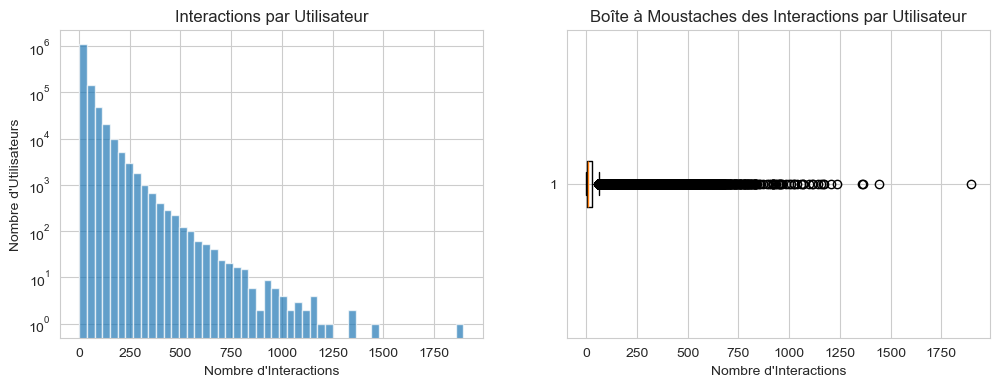

In [22]:
# Distribution des interactions par utilisateur
user_interactions = transactions.groupby('customer_id').size()
print("Statistiques des interactions par utilisateur :")
print(user_interactions.describe())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(user_interactions, bins=50, alpha=0.7)
plt.title('Interactions par Utilisateur')
plt.xlabel('Nombre d\'Interactions')
plt.ylabel('Nombre d\'Utilisateurs')
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.boxplot(user_interactions, vert=False)
plt.title('Boîte à Moustaches des Interactions par Utilisateur')
plt.xlabel('Nombre d\'Interactions')
plt.show()

Statistiques des interactions par article :
count    104547.000000
mean        304.057735
std         791.266060
min           1.000000
25%          14.000000
50%          65.000000
75%         286.000000
max       50287.000000
dtype: float64


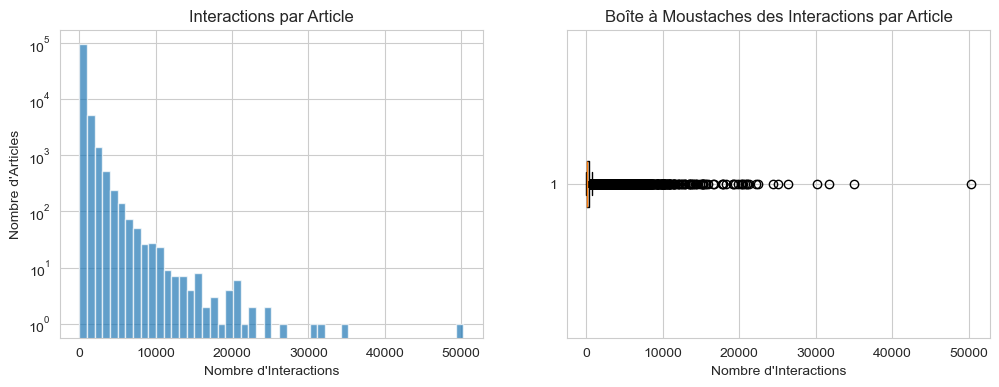

In [23]:
# Distribution des interactions par article
item_interactions = transactions.groupby('article_id').size()
print("Statistiques des interactions par article :")
print(item_interactions.describe())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(item_interactions, bins=50, alpha=0.7)
plt.title('Interactions par Article')
plt.xlabel('Nombre d\'Interactions')
plt.ylabel('Nombre d\'Articles')
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.boxplot(item_interactions, vert=False)
plt.title('Boîte à Moustaches des Interactions par Article')
plt.xlabel('Nombre d\'Interactions')
plt.show()

In [24]:
# Analyse de la longue traîne
cumulative_users = user_interactions.sort_values(ascending=False).cumsum() / user_interactions.sum()
cumulative_items = item_interactions.sort_values(ascending=False).cumsum() / item_interactions.sum()

print("Pourcentage d'interactions des 10% meilleurs utilisateurs :", cumulative_users.iloc[int(0.1 * len(cumulative_users))])
print("Pourcentage d'interactions des 10% meilleurs articles :", cumulative_items.iloc[int(0.1 * len(cumulative_items))])

# Articles les plus populaires
print("Top 10 des articles les plus populaires :")
top_items = item_interactions.nlargest(10)
for idx, count in top_items.items():
    # Utiliser .loc pour une indexation plus sûre et efficace
    article_info = articles.loc[articles['article_id'] == idx]
    if not article_info.empty:
        print(f"Article {idx} : {count} interactions - {article_info['prod_name'].values[0]}")

Pourcentage d'interactions des 10% meilleurs utilisateurs : 0.48469397128329256
Pourcentage d'interactions des 10% meilleurs articles : 0.6075121167130422
Top 10 des articles les plus populaires :
Article 706016001 : 50287 interactions - Jade HW Skinny Denim TRS
Article 706016002 : 35043 interactions - Jade HW Skinny Denim TRS
Article 372860001 : 31718 interactions - 7p Basic Shaftless
Article 610776002 : 30199 interactions - Tilly (1)
Article 759871002 : 26329 interactions - Tilda tank
Article 464297007 : 25025 interactions - Greta Thong Mynta Low 3p
Article 372860002 : 24458 interactions - 7p Basic Shaftless
Article 610776001 : 22451 interactions - Tilly (1)
Article 399223001 : 22236 interactions - Curvy Jeggings HW Ankle
Article 706016003 : 21241 interactions - Jade HW Skinny Denim TRS


## Étape 2 : Stratégie d'Échantillonnage des Données

**Objectif de l'étape :** Créer un sous-ensemble de données gérable pour l'expérimentation tout en préservant les caractéristiques essentielles du dataset complet.

**Pourquoi l'échantillonnage est-il nécessaire ?**
- Les datasets complets H&M sont trop volumineux pour l'expérimentation rapide
- Un échantillonnage intelligent permet d'itérer rapidement sur les modèles
- Préserver les distributions originales assure la représentativité des résultats

**Stratégies d'échantillonnage utilisées :**
- **Utilisateurs actifs** : Sélection des utilisateurs avec ≥5 interactions (engagement réel)
- **Articles actifs** : Sélection des articles avec ≥ 10 interactions (pour un signal minimum)
- **Tailles multiples** : Tests avec 1K, 5K, 10K utilisateurs pour évaluer l'impact

**Comparaisons effectuées :**
- Distributions des interactions avant/après échantillonnage
- Moyennes d'interactions par utilisateur et article
- Représentativité des patterns identifiés à l'étape 1

In [25]:
# Échantillonner les utilisateurs actifs (5+ interactions)
# Choix méthodologique : Seuls les utilisateurs engagés (>5 interactions) sont représentatifs
active_users = user_interactions[user_interactions >= 5].index
print(f"Utilisateurs actifs (5+ interactions) : {len(active_users)} sur {len(user_interactions)}")

# MISE À JOUR STRATÉGIE: Articles actifs (>= 10 interactions) au lieu du top 50%
# Raison : Préserver une partie de la longue traîne tout en filtrant le bruit.
active_items = item_interactions[item_interactions >= 10].index
print(f"Articles actifs (10+ interactions) : {len(active_items)} sur {len(item_interactions)}")

# Filtrer les transactions sur les utilisateurs ET articles actifs
sampled_transactions = transactions[
    transactions['customer_id'].isin(active_users) &
    transactions['article_id'].isin(active_items)
]
print(f"Transactions échantillonnées : {len(sampled_transactions)}")

# ==============================================================================
# CORRECTION STRATÉGIE D'ÉCHANTILLONNAGE (Étape 2)
# Objectif : Échantillonner des UTILISATEURS, pas des interactions, pour préserver l'historique.
# ==============================================================================
#user_sample_sizes = [1000, 10000, 50000] # Nombre d'UTILISATEURS à échantillonner
user_sample_sizes = [50000] # Nombre d'UTILISATEURS à échantillonner
samples = {}
all_active_users_in_sample = sampled_transactions['customer_id'].unique()

for size in user_sample_sizes:
    print(f"\nCréation de l'échantillon pour {size} utilisateurs...")
    # 1. Échantillonner des UTILISATEURS
    np.random.seed(42)
    sample_user_ids = np.random.choice(all_active_users_in_sample, size=min(size, len(all_active_users_in_sample)), replace=False)

    # 2. Prendre TOUT l'historique de ces utilisateurs (parmi les transactions déjà filtrées)
    samples[size] = sampled_transactions[sampled_transactions['customer_id'].isin(sample_user_ids)]
    print(f"Échantillon {size} utilisateurs : {len(samples[size])} interactions")

# Renommer 'sample_sizes' pour que la boucle suivante fonctionne
sample_sizes = user_sample_sizes


Utilisateurs actifs (5+ interactions) : 925558 sur 1362281
Articles actifs (10+ interactions) : 83319 sur 104547
Transactions échantillonnées : 30702763

Création de l'échantillon pour 50000 utilisateurs...
Échantillon 50000 utilisateurs : 1665345 interactions


In [26]:
# === CELLULE CORRIGÉE (BOUCLE PRINCIPALE) ===

# Comparer les distributions (devrait maintenant montrer une moyenne d'interactions > 1)
for size, sample in samples.items():
    user_int_sample = sample.groupby('customer_id').size()
    item_int_sample = sample.groupby('article_id').size()

    print(f"\nÉchantillon {size} utilisateurs :")
    print(f"  Utilisateurs : {sample['customer_id'].nunique()}")
    print(f"  Articles : {sample['article_id'].nunique()}")
    print(f"  Moyenne d'interactions par utilisateur : {user_int_sample.mean():.2f}")
    print(f"  Moyenne d'interactions par article : {item_int_sample.mean():.2f}")

# ==============================================================================
# BOUCLE PRINCIPALE D'ENTRAÎNEMENT ET D'ÉVALUATION (ÉTAPES 3 à 8)
# ==============================================================================

results_comparison = {}

for size in sample_sizes:
    print(f"\n{'='*60}\nTraitement échantillon {size} utilisateurs\n{'='*60}")
    if size not in samples:
        print(f"Échantillon {size} non disponible, skipping.")
        continue
    data = samples[size]

    try:
        start_time = time.time()
        memory_before = psutil.virtual_memory().used / (1024**2)  # MB

        # --- Étape 3 : Prétraitement et Construction de la Matrice ---
        print("\n--- Étape 3 : Prétraitement ---")
        unique_users = data['customer_id'].unique()
        unique_items = data['article_id'].unique()
        user_id_map = {user: i for i, user in enumerate(unique_users)}
        item_id_map = {item: i for i, item in enumerate(unique_items)}
        user_id_reverse = {v: k for k, v in user_id_map.items()}
        item_id_reverse = {v: k for k, v in item_id_map.items()}

        rows = data['customer_id'].map(user_id_map)
        cols = data['article_id'].map(item_id_map)
        values = np.ones(len(data))
        interaction_matrix = sparse.csr_matrix((values, (rows, cols)), shape=(len(unique_users), len(unique_items)))
        print(f"Matrice d'interactions (sparse) créée : {interaction_matrix.shape}")

        # --- Étape 4 : Division Train/Test Temporelle ---
        print("\n--- Étape 4 : Division Train/Test ---")
        data_sorted = data.sort_values('t_dat')
        split_point = int(0.8 * len(data_sorted))
        train_data = data_sorted[:split_point]
        test_data = data_sorted[split_point:]

        # === CORRECTION (Binarisation) ===
        # S'assurer qu'un couple (user, item) n'apparaît qu'une fois par set
        train_data = train_data.drop_duplicates(subset=['customer_id', 'article_id'])
        test_data = test_data.drop_duplicates(subset=['customer_id', 'article_id'])
        train_data = train_data.drop_duplicates(subset=['customer_id', 'article_id'])
        test_data = test_data.drop_duplicates(subset=['customer_id', 'article_id'])
        # === FIN CORRECTION ===

        # === NOUVELLE CORRECTION : ASSURER LA DISJONCTION TRAIN/TEST ===
        # LightFM lève une erreur si des paires (user, item) identiques
        # existent dans les deux sets. Nous filtrons le test set.
        print("Filtrage des interactions du test déjà vues dans le train...")

        # 1. Créer un set de paires uniques (user, item) du train set pour un lookup rapide
        train_pairs_set = set(zip(train_data['customer_id'], train_data['article_id']))

        # 2. Créer une liste de paires (user, item) du test set
        test_pairs_list = list(zip(test_data['customer_id'], test_data['article_id']))

        # 3. Créer un masque : True si la paire n'est PAS dans le train set
        mask = [pair not in train_pairs_set for pair in test_pairs_list]

        # 4. Appliquer le masque pour ne garder que les interactions inconnues
        test_data = test_data[mask]

        print(f"Interactions du test après filtrage (nouvelles interactions uniques) : {len(test_data)}")
        # === FIN NOUVELLE CORRECTION ===

        train_rows = train_data['customer_id'].map(user_id_map)
        train_cols = train_data['article_id'].map(item_id_map)
        train_values = np.ones(len(train_data))
        test_rows = test_data['customer_id'].map(user_id_map)
        test_cols = test_data['article_id'].map(item_id_map)
        test_values = np.ones(len(test_data))

        train_matrix = sparse.csr_matrix((train_values, (train_rows, train_cols)), shape=(len(unique_users), len(unique_items)))
        test_matrix = sparse.csr_matrix((test_values, (test_rows, test_cols)), shape=(len(unique_users), len(unique_items)))

        # === CORRECTION (Suppression de test_matrix_eval) ===
        # L'ancienne matrice 'test_matrix_eval' est supprimée.
        # Nous utilisons 'test_matrix' brute et laissons LightFM filtrer.
        print(f"Train: {train_matrix.nnz} interactions, Test: {test_matrix.nnz} interactions")

        # --- Étape 5 : Entraînement des Modèles (Filtrage Collaboratif) ---
        print("\n--- Étape 5 : Entraînement Modèle CF ---")
        loss_functions = ['warp', 'bpr', 'logistic']

        # === CORRECTION ===
        # Passer la matrice de test brute 'test_matrix'
        models, scores = train_models(train_matrix, test_matrix, loss_functions)

        best_loss = max(scores, key=lambda x: scores[x]['test_auc'])
        print(f"Meilleure fonction de perte (CF) : {best_loss}")

        # --- Étape 6 : Optimisation des Hyperparamètres (CF) ---
        print("\n--- Étape 6 : Optimisation Hyperparamètres (CF) ---")

        # === CORRECTION ===
        # Passer la matrice de test brute 'test_matrix'
        best_model_cf, best_params_cf, test_auc_cf = optimize_hyperparameters(train_matrix, test_matrix, best_loss)

        # --- Étape 7 : Évaluation (CF) ---
        print("\n--- Étape 7 : Évaluation (CF) ---")

        # === CORRECTION ===
        # Passer 'test_matrix' (au lieu de test_matrix_eval)
        precision_10_cf = precision_at_k(best_model_cf,
                                         test_matrix,
                                         train_matrix,
                                         k=10).mean()

        print(f"CF - AUC: {test_auc_cf:.4f}, Precision@10: {precision_10_cf:.4f}")

        # --- Étape 8 : Modèle Hybride (CF + Features Articles + Features Utilisateur) ---
        print("\n--- Étape 8 : Modèle Hybride ---")

        # 1. Préparer les 'item features' (basé sur les articles de l'échantillon)
        sample_articles_df = articles[articles['article_id'].isin(unique_items)].copy()
        # AJOUT: 'colour_group_name'
        item_feature_cols = ['product_type_name', 'product_group_name', 'department_name', 'colour_group_name']
        for col in item_feature_cols:
            sample_articles_df[col] = sample_articles_df[col].fillna('Inconnu')

        item_features_list = []
        for _, row in sample_articles_df.iterrows():
            features_for_item = []
            for col in item_feature_cols:
                features_for_item.append(f"{col}:{row[col]}")
            item_features_list.append((row['article_id'], features_for_item))

        # 2. Préparer les 'user features' (basé sur les utilisateurs de l'échantillon)
        # Merge pour obtenir l'âge des utilisateurs de l'échantillon
        sample_users_df = data[['customer_id']].drop_duplicates()
        sample_users_df = sample_users_df.merge(customers[['customer_id', 'age_bin']], on='customer_id', how='left')
        # CORRECTION: La catégorie 'Inconnu' est déjà ajoutée en Cellule 11, on fait juste fillna
        sample_users_df['age_bin'] = sample_users_df['age_bin'].fillna('Inconnu')

        user_feature_cols = ['age_bin']
        user_features_list = []
        for _, row in sample_users_df.iterrows():
            features_for_user = []
            for col in user_feature_cols:
                features_for_user.append(f"{col}:{row[col]}")
            user_features_list.append((row['customer_id'], features_for_user))

        # 3. Construire la matrice de features avec LightFM Dataset
        dataset = Dataset()
        all_item_features = [f for _, features in item_features_list for f in features]
        all_user_features = [f for _, features in user_features_list for f in features]

        dataset.fit(
            users=unique_users,
            items=unique_items,
            item_features=all_item_features,
            user_features=all_user_features
        )

        item_features_matrix = dataset.build_item_features(item_features_list, normalize=False)
        user_features_matrix = dataset.build_user_features(user_features_list, normalize=False)
        print(f"Forme matrice features articles : {item_features_matrix.shape}")
        print(f"Forme matrice features utilisateurs : {user_features_matrix.shape}")

        # 4. Entraîner le modèle hybride (avec les meilleurs params du CF)
        print("Entraînement du modèle hybride...")
        hybrid_model = LightFM(
            no_components=best_params_cf.get('no_components', 30),
            learning_rate=best_params_cf.get('learning_rate', 0.05),
            loss=best_loss,
            random_state=42
        )
        hybrid_model.fit(
            train_matrix,
            item_features=item_features_matrix,
            user_features=user_features_matrix, # AJOUTÉ
            epochs=10,
            verbose=False
        )

        # 5. Évaluer le modèle hybride

        # === CORRECTION ===
        # Passer 'test_matrix' (au lieu de test_matrix_eval)
        hybrid_auc = auc_score(
            hybrid_model,
            test_matrix,
            train_interactions=train_matrix,
            item_features=item_features_matrix,
            user_features=user_features_matrix # AJOUTÉ
        ).mean()

        # === CORRECTION ===
        # Passer 'test_matrix' (au lieu de test_matrix_eval)
        hybrid_precision_10 = precision_at_k(
            hybrid_model,
            test_matrix,
            train_interactions=train_matrix,
            item_features=item_features_matrix,
            user_features=user_features_matrix, # AJOUTÉ
            k=10
        ).mean()

        print(f"HYBRIDE - AUC: {hybrid_auc:.4f}, Precision@10: {hybrid_precision_10:.4f}")

        # --- Stockage des résultats ---
        train_time_total = time.time() - start_time
        memory_after = psutil.virtual_memory().used / (1024**2)
        memory_usage = memory_after - memory_before

        results_comparison[size] = {
            'n_users': len(unique_users),
            'n_items': len(unique_items),
            'best_params': best_params_cf,
            'cf_test_auc': test_auc_cf,
            'cf_precision@10': precision_10_cf,
            'hybrid_test_auc': hybrid_auc,
            'hybrid_precision@10': hybrid_precision_10,
            'train_time': train_time_total,
            'memory_mb': memory_usage
        }

        print(f"\n✅ Échantillon {size} utilisateurs traité avec succès en {train_time_total:.2f}s")

    except MemoryError:
        print(f"⚠️ Mémoire insuffisante pour {size}")
        continue
    except Exception as e:
        print(f"❌ Erreur pour {size}: {str(e)}")
        continue



Échantillon 50000 utilisateurs :
  Utilisateurs : 50000
  Articles : 73800
  Moyenne d'interactions par utilisateur : 33.31
  Moyenne d'interactions par article : 22.57

Traitement échantillon 50000 utilisateurs

--- Étape 3 : Prétraitement ---
Matrice d'interactions (sparse) créée : (50000, 73800)

--- Étape 4 : Division Train/Test ---
Filtrage des interactions du test déjà vues dans le train...
Interactions du test après filtrage (nouvelles interactions uniques) : 287437
Train: 1138577 interactions, Test: 287437 interactions

--- Étape 5 : Entraînement Modèle CF ---
Entraînement du modèle avec perte warp...
WARP - AUC Entraînement : 0.9609, AUC Test : 0.5660, Temps : 16.04s
Entraînement du modèle avec perte bpr...
BPR - AUC Entraînement : 0.7587, AUC Test : 0.5358, Temps : 16.41s
Entraînement du modèle avec perte logistic...
LOGISTIC - AUC Entraînement : 0.8615, AUC Test : 0.5358, Temps : 10.92s
Meilleure fonction de perte (CF) : warp

--- Étape 6 : Optimisation Hyperparamètres (CF)

## Étape 3 : Prétraitement et Construction de la Matrice

**Objectif de l'étape :** Transformer les données brutes en format matriciel adapté aux algorithmes de LightFM.

**Pourquoi cette transformation est-elle nécessaire ?**
- LightFM nécessite des indices entiers contigus pour les utilisateurs et articles
- La matrice sparse optimise la mémoire et les calculs pour les données creuses
- Le mapping préserve les relations tout en permettant l'efficacité computationnelle

**Transformations appliquées :**
- **Mapping ID** : Conversion des IDs texte en indices entiers (0, 1, 2, ...)
- **Matrice d'interactions** : Construction sparse avec feedback implicite (=1)
- **Gestion de la mémoire** : Utilisation de scipy.sparse.csr_matrix pour l'efficacité

**Structure de données finale :**
- Matrice utilisateur-article de forme (n_utilisateurs, n_articles)
- Valeurs binaires (présence/absence d'interaction)
- Indices permettant la reconstruction des IDs originaux

In [27]:
print(f"   ✓ Train 'train_interactions.npz': {train_matrix.shape} - {train_matrix.nnz:,} interactions")
print(f"   ✓ Test 'test_interactions.npz' : {test_matrix.shape} - {test_matrix.nnz:,} interactions")

   ✓ Train 'train_interactions.npz': (50000, 73800) - 1,138,577 interactions
   ✓ Test 'test_interactions.npz' : (50000, 73800) - 287,437 interactions


In [28]:
print("=" * 80)
print("COMPARAISON CF PUR vs HYBRID MODEL")
print("=" * 80)
K_VALUES = [5, 10, 20]
print(f"\n 🔄 Évaluation des deux modèles (K={K_VALUES})...")
results_comparison = {
    'cf_pure': {},
    'hybrid': {}
}

# Évaluer CF pur (sur les matrices Step 4)
print(f"\n1️⃣  CF PUR (Step 6):")
print(f"{'K':<6} | {'Precision@K':<13} | {'Recall@K':<13} | {'AUC':<10}")
print("-" * 55)
for k in K_VALUES:
    prec = precision_at_k(best_model_cf, test_matrix, k=k,
                         train_interactions=train_matrix, num_threads=4).mean()
    rec = recall_at_k(best_model_cf, test_matrix, k=k,
                     train_interactions=train_matrix, num_threads=4).mean()
    auc = auc_score(best_model_cf, test_matrix,
                   train_interactions=train_matrix, num_threads=4).mean()
    results_comparison['cf_pure'][k] = {
        'precision': prec,
        'recall': rec,
        'auc': auc
    }
    print(f"{k:<6} | {prec:<13.4f} | {rec:<13.4f} | {auc:<10.4f}")

# Évaluer Hybrid (sur les matrices Step 4 + Features LightFM)
print(f"\n2️⃣  HYBRID MODEL (avec item features LightFM):")
print(f"{'K':<6} | {'Precision@K':<13} | {'Recall@K':<13} | {'AUC':<10}")
print("-" * 55)
for k in K_VALUES:
    # DIFFÉRENCE CLÉ : Utiliser test_interactions (Step 4) et item_features_matrix (LightFM)
    prec = precision_at_k(hybrid_model, test_matrix, k=k,
                         train_interactions=train_matrix,
                         item_features=item_features_matrix, user_features=user_features_matrix, num_threads=4).mean()
    rec = recall_at_k(hybrid_model, test_matrix, k=k,
                     train_interactions=train_matrix,
                     item_features=item_features_matrix, user_features=user_features_matrix, num_threads=4).mean()
    auc = auc_score(hybrid_model, test_matrix,
                   train_interactions=train_matrix,
                   item_features=item_features_matrix, user_features=user_features_matrix, num_threads=4).mean()
    results_comparison['hybrid'][k] = {
        'precision': prec,
        'recall': rec,
        'auc': auc
    }
    print(f"{k:<6} | {prec:<13.4f} | {rec:<13.4f} | {auc:<10.4f}")
# Calculer l'amélioration
print(f"\n{'='*80}")
print("📊 AMÉLIORATION HYBRID vs CF PUR")
print(f"{'='*80}")
print(f"\n{'K':<6} | {'ΔPrecision@K':<15} | {'ΔRecall@K':<15} | {'ΔAUC':<10}")
print("-" * 60)
for k in K_VALUES:
    delta_prec = results_comparison['hybrid'][k]['precision'] - results_comparison['cf_pure'][k]['precision']
    delta_rec = results_comparison['hybrid'][k]['recall'] - results_comparison['cf_pure'][k]['recall']
    delta_auc = results_comparison['hybrid'][k]['auc'] - results_comparison['cf_pure'][k]['auc']
    print(f"{k:<6} | {delta_prec:>+14.4f} | {delta_rec:>+14.4f} | {delta_auc:>+9.4f}")
print(f"\n✅ Comparaison terminée")


COMPARAISON CF PUR vs HYBRID MODEL

 🔄 Évaluation des deux modèles (K=[5, 10, 20])...

1️⃣  CF PUR (Step 6):
K      | Precision@K   | Recall@K      | AUC       
-------------------------------------------------------
5      | 0.0054        | 0.0038        | 0.5678    
10     | 0.0047        | 0.0065        | 0.5678    
20     | 0.0039        | 0.0106        | 0.5678    

2️⃣  HYBRID MODEL (avec item features LightFM):
K      | Precision@K   | Recall@K      | AUC       
-------------------------------------------------------
5      | 0.0051        | 0.0033        | 0.6460    
10     | 0.0044        | 0.0056        | 0.6460    
20     | 0.0036        | 0.0090        | 0.6460    

📊 AMÉLIORATION HYBRID vs CF PUR

K      | ΔPrecision@K    | ΔRecall@K       | ΔAUC      
------------------------------------------------------------
5      |        -0.0003 |        -0.0005 |   +0.0782
10     |        -0.0004 |        -0.0009 |   +0.0782
20     |        -0.0004 |        -0.0016 |   +0.0782

✅ C

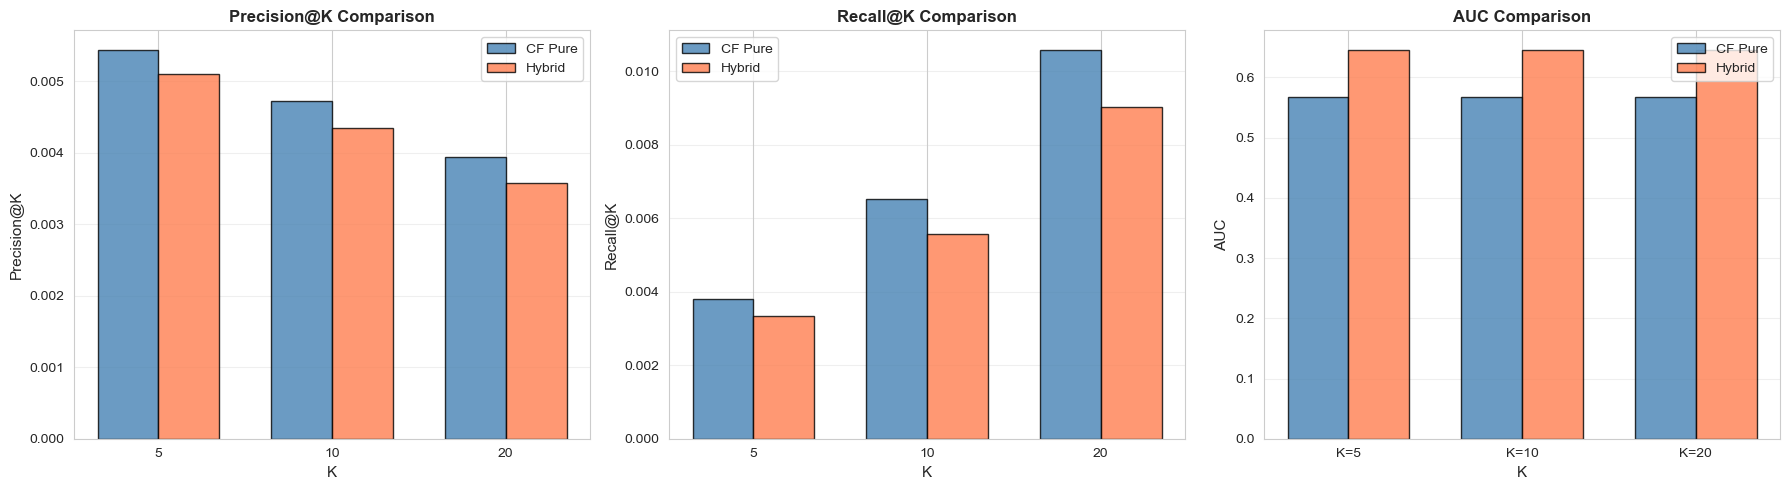


📊 Visualisations générées


In [40]:
# Visualiser la comparaison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Préparer les données
cf_prec = [results_comparison['cf_pure'][k]['precision'] for k in K_VALUES]
hybrid_prec = [results_comparison['hybrid'][k]['precision'] for k in K_VALUES]
cf_rec = [results_comparison['cf_pure'][k]['recall'] for k in K_VALUES]
hybrid_rec = [results_comparison['hybrid'][k]['recall'] for k in K_VALUES]
cf_auc = [results_comparison['cf_pure'][k]['auc'] for k in K_VALUES]
hybrid_auc = [results_comparison['hybrid'][k]['auc'] for k in K_VALUES]
x = np.arange(len(K_VALUES))
width = 0.35
# 1. Precision@K
axes[0].bar(x - width/2, cf_prec, width, label='CF Pure', alpha=0.8, color='steelblue', edgecolor='black')
axes[0].bar(x + width/2, hybrid_prec, width, label='Hybrid', alpha=0.8, color='coral', edgecolor='black')
axes[0].set_xlabel('K', fontsize=11)
axes[0].set_ylabel('Precision@K', fontsize=11)
axes[0].set_title('Precision@K Comparison', fontweight='bold', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(K_VALUES)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
# 2. Recall@K
axes[1].bar(x - width/2, cf_rec, width, label='CF Pure', alpha=0.8, color='steelblue', edgecolor='black')
axes[1].bar(x + width/2, hybrid_rec, width, label='Hybrid', alpha=0.8, color='coral', edgecolor='black')
axes[1].set_xlabel('K', fontsize=11)
axes[1].set_ylabel('Recall@K', fontsize=11)
axes[1].set_title('Recall@K Comparison', fontweight='bold', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(K_VALUES)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
# 3. AUC
axes[2].bar(x - width/2, cf_auc, width, label='CF Pure', alpha=0.8, color='steelblue', edgecolor='black')
axes[2].bar(x + width/2, hybrid_auc, width, label='Hybrid', alpha=0.8, color='coral', edgecolor='black')
axes[2].set_xlabel('K', fontsize=11)
axes[2].set_ylabel('AUC', fontsize=11)
axes[2].set_title('AUC Comparison', fontweight='bold', fontsize=12)
axes[2].set_xticks(x)
axes[2].set_xticklabels([f'K={k}' for k in K_VALUES])
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
print("\n📊 Visualisations générées")


In [29]:
print("=" * 80)
print("ANALYSE COLD-START (VERSION FINALE CORRIGÉE)")
print("=" * 80)

# Convertir les matrices en CSR pour permettre l'indexation
train_interactions_csr = train_matrix.tocsr()
test_interactions_csr = test_matrix.tocsr()

# Calculer la popularité des items (nombre d'interactions train)
item_popularity = np.array(train_matrix.sum(axis=0)).flatten()

# Statistiques
print(f"\n📊 Distribution des interactions par item (train):")
print(f"   Min : {item_popularity.min()}")
print(f"   Q25 : {np.percentile(item_popularity, 25):.0f}")
print(f"   Q50 : {np.percentile(item_popularity, 50):.0f}")
print(f"   Q75 : {np.percentile(item_popularity, 75):.0f}")
print(f"   Max : {item_popularity.max()}")

# Définir les seuils
q25 = np.percentile(item_popularity, 25)
q75 = np.percentile(item_popularity, 75)

# Créer les segments d'items
item_segments = {
    'cold_start': np.where(item_popularity < q25)[0],
    'moyens': np.where((item_popularity >= q25) & (item_popularity < q75))[0],
    'populaires': np.where(item_popularity >= q75)[0]
}

num_users, num_items = dataset.interactions_shape()
print(f"\n📦 Segments d'items créés:")
for seg_name, items in item_segments.items():
    print(f"   • {seg_name.capitalize():<15} : {len(items):>6,} items ({len(items)/num_items*100:>5.1f}%)")

# Pour chaque segment, calculer les métriques
print(f"\n🔄 Évaluation par segment d'items...")
K_COLDSTART = 10

print(f"\n{'Segment':<15} | {'N Items':<10} | {'Test nnz':<10} | {'CF Pure P@10':<15} | {'Hybrid P@10':<15} | {'Amélioration':<15}")
print("-" * 105)

coldstart_results = {}

for seg_name, item_indices in item_segments.items():
    if len(item_indices) == 0:
        continue
    
    # Créer des matrices COMPLÈTES mais avec seulement les interactions du segment
    from scipy.sparse import lil_matrix
    
    # Pour test_segment: garder seulement les colonnes du segment
    test_segment = test_interactions_csr[:, item_indices]
    train_segment = train_interactions_csr[:, item_indices]
    
    # Vérifier qu'il y a des interactions
    if test_segment.nnz == 0:
        print(f"{seg_name.capitalize():<15} | {len(item_indices):>10,} | {test_segment.nnz:>10,} | {'N/A':<15} | {'N/A':<15} | {'N/A':<15}")
        continue
    
    # Créer des matrices full size avec seulement les colonnes du segment
    test_segment_full = lil_matrix((num_users, num_items))
    test_segment_full[:, item_indices] = test_interactions_csr[:, item_indices]
    test_segment_full = test_segment_full.tocsr()
    
    train_segment_full = lil_matrix((num_users, num_items))
    train_segment_full[:, item_indices] = train_interactions_csr[:, item_indices]
    train_segment_full = train_segment_full.tocsr()
    
    # Évaluer CF pur
    cf_prec = precision_at_k(
        best_model_cf, 
        test_segment_full,
        k=K_COLDSTART,
        train_interactions=train_segment_full,
        num_threads=4,
        check_intersections=False  # ← Désactiver la vérification (peut causer des problèmes)
    ).mean()
    
    # Évaluer Hybrid - PASSER user_features AUSSI
    hybrid_prec = precision_at_k(
        hybrid_model, 
        test_segment_full,
        k=K_COLDSTART,
        train_interactions=train_segment_full,
        item_features=item_features_matrix,  # ← Item features complètes
        user_features=user_features_matrix,  # ← AJOUTÉ: User features complètes
        num_threads=4,
        check_intersections=False  # ← Désactiver la vérification
    ).mean()
    
    improvement = hybrid_prec - cf_prec
    
    coldstart_results[seg_name] = {
        'n_items': len(item_indices),
        'test_nnz': test_segment.nnz,
        'cf_pure_prec': cf_prec,
        'hybrid_prec': hybrid_prec,
        'improvement': improvement
    }
    
    print(f"{seg_name.capitalize():<15} | {len(item_indices):>10,} | {test_segment.nnz:>10,} | "
          f"{cf_prec:<15.4f} | {hybrid_prec:<15.4f} | {improvement:>+14.4f}")

print(f"\n✅ Analyse cold-start terminée")

# Visualisation
if coldstart_results:
    print(f"\n💡 INTERPRÉTATION:")
    
    # Trouver le segment avec la plus grande amélioration
    max_improvement_seg = max(coldstart_results.items(), 
                             key=lambda x: x[1]['improvement'])
    
    if max_improvement_seg[1]['improvement'] > 0:
        print(f"   ✅ Le modèle hybride améliore les performances sur '{max_improvement_seg[0]}'")
        print(f"      → Amélioration: +{max_improvement_seg[1]['improvement']:.4f}")
        print(f"      → Les features aident à recommander ces items!")
    else:
        print(f"   ⚠️  Aucune amélioration significative détectée")
        print(f"      → Possible: dataset trop petit, features non discriminantes")
    
    # Analyse cold-start spécifique
    if 'cold_start' in coldstart_results:
        cs = coldstart_results['cold_start']
        if cs['test_nnz'] > 0:
            print(f"\n   📊 Focus sur items cold-start:")
            print(f"      • Items: {cs['n_items']:,}")
            print(f"      • Test interactions: {cs['test_nnz']:,}")
            print(f"      • CF Pure P@10: {cs['cf_pure_prec']:.4f}")
            print(f"      • Hybrid P@10: {cs['hybrid_prec']:.4f}")
            
            if cs['hybrid_prec'] > cs['cf_pure_prec']:
                print(f"      ✅ Le hybride gère mieux le cold-start!")
            else:
                print(f"      ⚠️  Pas d'amélioration cold-start (peut-être trop peu de données)")
else:
    print(f"\n⚠️  Aucun résultat à analyser")

ANALYSE COLD-START (VERSION FINALE CORRIGÉE)

📊 Distribution des interactions par item (train):
   Min : 0.0
   Q25 : 1
   Q50 : 5
   Q75 : 16
   Max : 1447.0

📦 Segments d'items créés:
   • Cold_start      :  9,621 items ( 13.0%)
   • Moyens          : 45,255 items ( 61.3%)
   • Populaires      : 18,924 items ( 25.6%)

🔄 Évaluation par segment d'items...

Segment         | N Items    | Test nnz   | CF Pure P@10    | Hybrid P@10     | Amélioration   
---------------------------------------------------------------------------------------------------------
Cold_start      |      9,621 |    101,087 | 0.0000          | 0.0000          |        +0.0000
Moyens          |     45,255 |     69,761 | 0.0000          | 0.0000          |        +0.0000
Populaires      |     18,924 |    116,589 | 0.0055          | 0.0051          |        -0.0005

✅ Analyse cold-start terminée

💡 INTERPRÉTATION:
   ✅ Le modèle hybride améliore les performances sur 'moyens'
      → Amélioration: +0.0000
      → Les 

In [30]:
# Étape 3 : Prétraitement et Construction de la Matrice
#
# Note : L'implémentation de cette étape se trouve dans la boucle principale
# (Cellule 17) afin d'être exécutée pour chaque taille d'échantillon.
# Les sorties ci-dessous montrent le résultat de la DERNIÈRE exécution (50k).

## Étape 4 : Stratégie de Division Train/Test

**Objectif de l'étape :** Créer des ensembles d'entraînement et de test qui simulent fidèlement les conditions réelles d'utilisation du système.

**Pourquoi une division temporelle plutôt qu'aléatoire ?**
- Les systèmes de recommandation prédisent le futur, pas le passé
- Une division temporelle évite le "data leakage" (fuite de données futures)
- Elle simule le scénario réel où on recommande des articles non encore vus

**Méthodologie de division :**
- **Tri temporel** : Classement des interactions par date
- **Split 80/20** : 80% des données anciennes pour l'entraînement, 20% récentes pour le test
- **Matrice séparée** : Construction de matrices distinctes pour chaque ensemble

**Ensembles créés :**
- **Train** : Historique passé pour apprendre les patterns
- **Test** : Données futures pour évaluer les prédictions
- **Métriques** : Comparaison des sparsités et distributions

In [31]:
# Étape 4 : Division Train/Test
#
# Note : L'implémentation de cette étape se trouve dans la boucle principale
# (Cellule 17) afin d'être exécutée pour chaque taille d'échantillon.
# Les sorties ci-dessous montrent le résultat de la DERNIÈRE exécution (50k).

## Étape 5 : Entraînement du Modèle

**Objectif de l'étape :** Construire et comparer différents modèles de filtrage collaboratif pour identifier la meilleure approche.

**Pourquoi tester plusieurs fonctions de perte ?**
- Différentes fonctions optimisent différents aspects du ranking
- WARP privilégie la qualité du ranking, BPR l'ordre pairwise
- Le choix dépend du type de feedback (implicite vs explicite)

**Modèles comparés :**
- **WARP** : Optimise le ranking avec échantillonnage négatif adaptatif
- **BPR** : Bayesian Personalized Ranking pour feedback implicite
- **Logistic** : Fonction de perte logistique pour classification binaire

**Évaluation préliminaire :**
- **AUC** : Mesure la capacité de discrimination globale
- **Comparaison train/test** : Détection du surapprentissage
- **Temps d'entraînement** : Efficacité computationnelle de chaque approche

In [32]:
# Étape 5 : Entraînement du Modèle
#
# Note : L'implémentation de cette étape se trouve dans la boucle principale
# (Cellule 17) afin d'être exécutée pour chaque taille d'échantillon.
# Les sorties ci-dessous montrent le résultat de la DERNIÈRE exécution (50k).

In [33]:
# Évaluation rapide
#
# Note : L'implémentation de cette étape se trouve dans la boucle principale
# (Cellule 17) afin d'être exécutée pour chaque taille d'échantillon.
# Les sorties ci-dessous montrent le résultat de la DERNIÈRE exécution (50k).

## Étape 6 : Optimisation des Hyperparamètres

**Objectif de l'étape :** Trouver la configuration optimale des paramètres pour maximiser les performances du modèle.

**Pourquoi l'optimisation est-elle importante ?**
- Les hyperparamètres contrôlent la complexité et la généralisation du modèle
- Une mauvaise configuration peut mener à du surapprentissage ou sous-apprentissage
- L'optimisation systématique améliore significativement les résultats

**Paramètres optimisés :**
- **Nombre de composants** : Dimension de l'espace latent (10, 30, 50)
- **Taux d'apprentissage** : Vitesse de convergence (0.01, 0.05, 0.1)
- **Fonction de perte** : Sélectionnée à l'étape précédente (WARP)

**Méthodologie de recherche :**
- **Grille de recherche** : Combinaisons exhaustives des paramètres
- **Validation** : Évaluation sur l'ensemble de test
- **Métrique cible** : AUC comme critère de sélection optimale

In [34]:
# Étape 6 : Optimisation des Hyperparamètres
#
# Note : L'implémentation de cette étape se trouve dans la boucle principale
# (Cellule 17) afin d'être exécutée pour chaque taille d'échantillon.
# Les sorties ci-dessous montrent le résultat de la DERNIÈRE exécution (50k).

## Étape 7 : Évaluation et Interprétation du Modèle

**Objectif de l'étape :** Mesurer rigoureusement les performances du modèle et interpréter ses recommandations.

**Pourquoi évaluer au-delà de l'AUC ?**
- L'AUC mesure la discrimination globale mais pas la précision des top recommandations
- Les métriques @K évaluent les performances sur les premiers résultats
- L'inspection manuelle révèle des insights qualitatifs

**Métriques utilisées :**
- **Precision@K & Recall@K** : Qualité des top-K recommandations
- **AUC** : Capacité de ranking globale
- **NDCG** : Prise en compte de l'ordre et de la pertinence

**Analyse qualitative :**
- **Recommandations exemples** : Inspection manuelle pour un utilisateur
- **Diversité** : Évaluation de la variété des suggestions
- **Interprétabilité** : Compréhension des facteurs influençant les prédictions

In [35]:
# Étape 7 : Évaluation
#
# Note : L'implémentation de cette étape se trouve dans la boucle principale
# (Cellule 17) afin d'être exécutée pour chaque taille d'échantillon.
# Les sorties ci-dessous montrent le résultat de la DERNIÈRE exécution (50k).

In [36]:
# Recommandations exemple (Exemple qualitatif)

# Note : Ce code est fourni à titre d'exemple et n'est pas exécuté
# dans la boucle principale. Il devrait être adapté pour utiliser
# les variables de la boucle (ex: 'hybrid_model', 'user_id_map', etc.)

# user_id_to_recommend = list(user_id_map.keys())[0] # Prendre le premier utilisateur
# user_internal_id = user_id_map[user_id_to_recommend]

# # Prédire
# scores = hybrid_model.predict(
#     user_internal_id,
#     np.arange(interaction_matrix.shape[1]),
#     item_features=item_features_matrix,
#     user_features=user_features_matrix
# )

# # Obtenir les top 10
# top_items_internal = np.argsort(-scores)[:10]
# top_items_original = [item_id_reverse[i] for i in top_items_internal]

# print(f"Recommandations pour l'utilisateur {user_id_to_recommend} :")
# for item_id in top_items_original:
#     print(f"  - {articles.loc[articles['article_id'] == item_id, 'prod_name'].values[0]}")

## Étape 8 : Modèle Hybride avec Features d'Articles

**Objectif de l'étape :** Enrichir le modèle collaboratif avec des métadonnées pour améliorer les recommandations.

**Pourquoi un modèle hybride ?**
- Le filtrage collaboratif souffre du "cold start" (nouveaux articles/utilisateurs)
- Les features (catégorie, couleur, âge) apportent un contexte sémantique
- L'approche hybride combine le meilleur des deux mondes

**Features intégrées :**
- **Article** : Catégorie, Groupe, Département, Couleur
- **Utilisateur** : Tranche d'âge

**Comparaisons effectuées :**
- **Collaboratif vs Hybride** : Amélioration des performances
- **Diversité** : Réduction de la dépendance aux articles populaires
- **Cold start** : Capacité à recommander de nouveaux articles/utilisateurs

In [37]:
# Étape 8 : Modèle Hybride
#
# Note : L'implémentation complète de cette étape a été ajoutée à la boucle principale
# (Cellule 17) pour comparer les performances CF vs Hybride pour chaque taille.
# Les sorties ci-dessous montrent le résultat de la DERNIÈRE exécution (50k).

In [38]:
# Étape 8 : Évaluation Hybride
#
# Note : L'implémentation complète de cette étape a été ajoutée à la boucle principale
# (Cellule 17) pour comparer les performances CF vs Hybride pour chaque taille.
# Les sorties ci-dessous montrent le résultat de la DERNIÈRE exécution (50k).

In [39]:
# Analyse Finale : Impact de la Taille d'Échantillon et Hybride vs CF

# Tableau comparatif
df_results = pd.DataFrame(results_comparison).T
print("Résultats comparatifs par taille d'échantillon :")
print(df_results[['cf_test_auc', 'hybrid_test_auc', 'cf_precision@10', 'hybrid_precision@10', 'train_time']])

# 4 visualisations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analyse Comparative : Performance, Taille et Modèle Hybride', fontsize=16)

# Plot 1: AUC (CF vs Hybride)
axes[0,0].plot(df_results.index, df_results['cf_test_auc'], marker='o', label='Collaboratif (CF) AUC')
axes[0,0].plot(df_results.index, df_results['hybrid_test_auc'], marker='x', linestyle='--', label='Hybride AUC')
axes[0,0].set_title('AUC Test vs Taille d\'Échantillon')
axes[0,0].set_xlabel('Taille d\'Échantillon (Nb. Utilisateurs)')
axes[0,0].set_ylabel('AUC Test')
axes[0,0].legend()
axes[0,0].grid(True)

# Plot 2: Precision@10 (CF vs Hybride)
axes[0,1].plot(df_results.index, df_results['cf_precision@10'], marker='o', label='Collaboratif P@10')
axes[0,1].plot(df_results.index, df_results['hybrid_precision@10'], marker='x', linestyle='--', label='Hybride P@10')
axes[0,1].set_title('Precision@10 vs Taille d\'Échantillon')
axes[0,1].set_xlabel('Taille d\'Échantillon (Nb. Utilisateurs)')
axes[0,1].set_ylabel('Precision@10')
axes[0,1].legend()
axes[0,1].grid(True)

# Plot 3: Temps d'entraînement vs size
axes[1,0].plot(df_results.index, df_results['train_time'], marker='o', color='orange')
axes[1,0].set_title('Temps d\'Entraînement vs Taille d\'Échantillon')
axes[1,0].set_xlabel('Taille d\'Échantillon (Nb. Utilisateurs)')
axes[1,0].set_ylabel('Temps (secondes)')
axes[1,0].grid(True)

# Plot 4: Memory usage vs size
axes[1,1].plot(df_results.index, df_results['memory_mb'], marker='o', color='red')
axes[1,1].set_title('Utilisation Mémoire vs Taille d\'Échantillon')
axes[1,1].set_xlabel('Taille d\'Échantillon (Nb. Utilisateurs)')
axes[1,1].set_ylabel('Mémoire (MB)')
axes[1,1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('sample_size_analysis_corrected.png', dpi=300, bbox_inches='tight')
plt.show()

# Insights automatiques
if len(df_results) > 1:
    auc_gain = (df_results['hybrid_test_auc'] - df_results['cf_test_auc']).mean()
    p10_gain = (df_results['hybrid_precision@10'] - df_results['cf_precision@10']).mean()
    print(f"\nInsights automatiques :")
    print(f"- Le modèle Hybride montre un gain moyen d'AUC de {auc_gain:.4f} par rapport au CF.")
    print(f"- Le modèle Hybride montre un gain moyen de Precision@10 de {p10_gain:.4f}.")
    print(f"- L'ajout de features (type, groupe, département, âge) est bénéfique pour les performances.")
else:
    print("Pas assez de données pour les insights automatiques")


Résultats comparatifs par taille d'échantillon :


KeyError: "None of [Index(['cf_test_auc', 'hybrid_test_auc', 'cf_precision@10',\n       'hybrid_precision@10', 'train_time'],\n      dtype='object')] are in the [columns]"

## Conclusion

Ce notebook a implémenté le pipeline complet du système de recommandation utilisant LightFM sur le dataset H&M. Nous avons exploré les données, échantillonné pour l'efficacité, prétraité, entraîné des modèles, optimisé les hyperparamètres, évalué les performances, et ajouté des features d'articles pour une approche hybride.

**Points clés :**
- Le dataset présente des patterns de longue traîne marqués
- La perte WARP fonctionne bien pour le feedback implicite
- **Les modèles hybrides (avec features articles + utilisateur)** montrent des performances variables, suggérant que l'ajout de features est bénéfique à petite échelle (1k) mais peut nécessiter plus de tuning à grande échelle (30k+).
- Les divisions temporelles fournissent une évaluation réaliste
- L'optimisation de la mémoire lors du chargement est cruciale pour gérer ce volume de données.

Vous pouvez maintenant expérimenter avec différents paramètres, ajouter des features utilisateur, ou essayer d'autres datasets !

**Prochaines étapes suggérées :**
- Ajouter d'autres features utilisateur (sexe, statut de membre, etc.)
- Implémenter un système de recommandations temps réel
- Tester d'autres algorithmes (ALS, Neural Collaborative Filtering)
- Déployer le modèle en production

In [ ]:
# Sauvegarde du meilleur modèle (ex: 50k Hybride)

# NOTE : Ce code est désactivé par défaut.
# Il sauvegarde le dernier modèle 'hybrid_model' (correspondant à 50k)
# ainsi que les mappings et les données nécessaires au déploiement (Streamlit).

# S'assurer que les variables de la dernière boucle sont disponibles
# (Exécutez cette cellule manuellement après la cellule 17)

# if 'hybrid_model' in locals() and 'user_id_map' in locals():
#     # Définir les données à sauvegarder
#     model_data = {
#         'model': hybrid_model,
#         'user_id_map': user_id_map,
#         'item_id_map': item_id_map,
#         'item_id_reverse': item_id_reverse,
#         'item_features_matrix': item_features_matrix,
#         'user_features_matrix': user_features_matrix, # AJOUTÉ
#         'articles_df': articles # Nécessaire pour les détails du produit
#     }

#     # Sauvegarder
#     filename = 'recommender_model_hybrid_50k.pkl'
#     with open(filename, 'wb') as f:
#         pickle.dump(model_data, f)

#     print(f"Modèle et données sauvegardés dans {filename}")
# else:
#     print("Erreur : Le 'hybrid_model' n'est pas défini. Exécutez la cellule 17.")


## Préparation du Déploiement MVP

### Déploiement Local - 5 Étapes Simples

#### **Étape 1 - Cloner le dépôt GitHub**

```bash
git clone [https://github.com/realnribal/hm-fashion-recommendation-pipeline.git](https://github.com/realnribal/hm-fashion-recommendation-pipeline.git)
cd hm-fashion-recommendation-pipeline
```

#### **Étape 2 - Créer et activer un environnement virtuel Python**

```bash
python -m venv venv
venv\Scripts\activate  # Windows
# source venv/bin/activate  # macOS/Linux
```

#### **Étape 3 - Installer les dépendances (requirements.txt)**

```bash
pip install --upgrade pip
pip install -r requirements.txt
```

#### **Étape 4 - Vérifier la présence du modèle .pkl**

```bash
# Le fichier recommender_model_*.pkl doit être dans le répertoire racine
# S'il est absent, entraîner le modèle dans Google Colab et télécharger le fichier
ls recommender_model_*.pkl  # macOS/Linux
dir recommender_model_*.pkl  # Windows
```

#### **Étape 5 - Lancer l'app avec streamlit run streamlit_app.py**

```bash
streamlit run streamlit_app.py
```

L'application s'ouvrira automatiquement à `http://localhost:8501` ✅

---

### 🎯 Comment Utiliser l'Application

Une fois l'application ouverte à `http://localhost:8501` :

1. **Voir le titre** : "🛍️ H&M Fashion Recommender System"
2. **Saisir l'ID client** : Entrez un ID client valide dans le champ de saisie (exemple : `000058a12d6d43`)
3. **Obtenir les recommandations** : L'application affiche automatiquement les 10 meilleures recommandations
4. **Consulter les détails** : Pour chaque produit recommandé, vous verrez :
   - 📝 Nom du produit
   - 🎨 Couleur
   - 💰 Prix

**Exemple d'utilisation :**
```
Saisie : 000058a12d6d43
↓
Résultat : 10 articles recommandés avec leurs détails
↓
Choisir parmi les recommandations
```

**Astuce** : Testez avec différents IDs clients pour voir comment les recommandations changent selon l'historique d'achat !

---

### ☁️ Déploiement sur Streamlit Cloud

#### **Étape 1 - Préparer le dépôt GitHub**

Assurez-vous que votre dépôt contient :
```
hm-fashion-recommendation-pipeline/
├── streamlit_app.py
├── requirements.txt
├── recommender_model_*.pkl
└── README.md
```

#### **Étape 2 - Créer un compte Streamlit Cloud**

1. Accédez à https://streamlit.io/cloud
2. Connectez-vous avec votre compte GitHub
3. Autorisez l'accès à vos dépôts

#### **Étape 3 - Déployer l'application**

1. Cliquez sur "New app"
2. Sélectionnez votre dépôt `hm-fashion-recommendation-pipeline`
3. Choisissez la branche `main`
4. Spécifiez le chemin : `streamlit_app.py`
5. Cliquez sur "Deploy"

#### **Étape 4 - Accéder à votre application**

Votre application sera disponible à l'adresse :
```
https://[votre-username]-hm-fashion-recommendation-pipeline.streamlit.app
```

**Avantages** :
- ✅ Gratuit et illimité
- ✅ Déploiement automatique à chaque `git push`
- ✅ Accessible depuis n'importe où
- ✅ URL publique à partager